In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

daily_demand = pd.read_csv("../data/processed/daily_demand.csv")
daily_demand['order_date'] = pd.to_datetime(daily_demand['order_date'])

df_prophet = daily_demand[['order_date', 'total_qty']].rename(
    columns={'order_date': 'ds', 'total_qty': 'y'})

print(df_prophet.shape)
df_prophet.head()

Importing plotly failed. Interactive plots will not work.


(524, 2)


,ds,y
0,2025-01-22,16
1,2025-01-23,0
2,2025-01-24,0
3,2025-01-25,0
4,2025-01-26,0


17:32:12 - cmdstanpy - INFO - Chain [1] start processing
17:32:13 - cmdstanpy - INFO - Chain [1] done processing


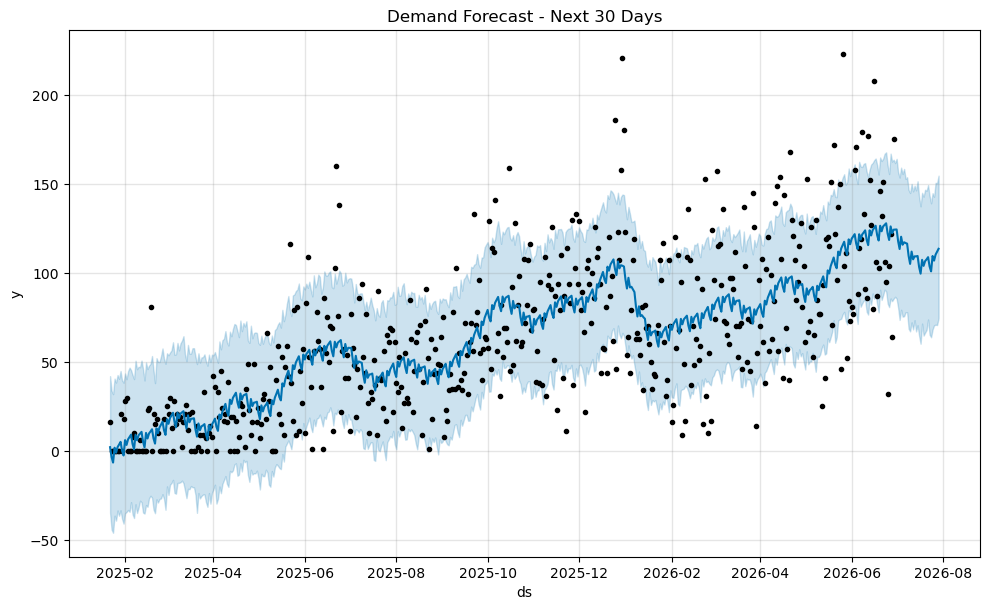

In [2]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title("Demand Forecast - Next 30 Days")
plt.show()

In [3]:
forecast_out = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(
    columns={'ds': 'date', 'yhat': 'predicted_qty',
             'yhat_lower': 'lower_bound', 'yhat_upper': 'upper_bound'})
forecast_out.to_csv("../reports/demand_forecast.csv", index=False)
print("Saved demand_forecast.csv")
forecast_out.tail(10)

Saved demand_forecast.csv


,date,predicted_qty,lower_bound,upper_bound
544,2026-07-20,106.609043,66.436178,146.731799
545,2026-07-21,107.610924,67.986039,146.140164
546,2026-07-22,108.848547,73.845213,149.323147
547,2026-07-23,103.662470,65.303930,143.350764
548,2026-07-24,100.861079,63.849453,139.085164
549,2026-07-25,109.507000,68.213232,144.777693
550,2026-07-26,106.904228,70.571397,142.778649
551,2026-07-27,110.258238,70.906157,150.608504
552,2026-07-28,111.848525,70.720766,150.378976
553,2026-07-29,113.549622,74.529144,154.632014
